## Collect ALL .txt File Paths With Labels

In [105]:
import os

DATA_ROOT = "Data"      # folder name exactly as in file explorer
TANK_DIR = os.path.join(DATA_ROOT, "Tank")   # Data/Tank
TRUCK_DIR = os.path.join(DATA_ROOT, "Truck") # Data//Truck

### Function to collect file

In [106]:
def collect_files(base_dir, label):
    files = []
    for root, _, filenames in os.walk(base_dir):
        for fname in filenames:
            if fname.lower().endswith(".txt"):
                full_path = os.path.join(root, fname)
                files.append((full_path, label))
    return files

### Collect Tank & Truck Files

In [107]:
tank_files = collect_files(TANK_DIR, label=1)
truck_files = collect_files(TRUCK_DIR, label=0)

print("Tank files :", len(tank_files))
print("Truck files:", len(truck_files))


Tank files : 128
Truck files: 139


### Read ONE .txt File (Ignore Last Column)

In [108]:
test_path, test_label = tank_files[0]

print("File path :", test_path)
print("Label     :", test_label)

File path : Data\Tank\BMP !! Tank Bhatinda\10km BBMP.txt
Label     : 1


### Function to Read File Safely 

In [109]:
import numpy as np

def read_vehicle_file(filepath):
    data = []

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()

            # skip empty lines or text headers
            if not line:
                continue
            if not (line[0].isdigit() or line[0] == '-'):
                continue

            parts = line.split()

            # take ONLY first 3 columns
            if len(parts) >= 3:
                try:
                    emf_abs = float(parts[0])     # Absolute
                    emf_diff = float(parts[1])    # Differential
                    seismic = float(parts[2])     # Seismic

                    # store in same order
                    data.append([emf_abs, emf_diff, seismic])

                except ValueError:
                    continue

    return np.array(data)

### Read the File.

In [110]:
signal = read_vehicle_file(test_path)

signal.shape

(391935, 3)

### Total files

In [111]:
all_files = tank_files + truck_files

print("Total files:", len(all_files))

Total files: 267


In [112]:
# all_signals = []
# all_labels = []
# all_paths = []

# for i, (filepath, label) in enumerate(all_files):
#     if i % 50 == 0:
#         print(f"Reading {i}/{len(all_files)}")
#     # print(f"Reading file {i+1}/{len(all_files)}")

#     signal = read_vehicle_file(filepath)

#     if signal.shape[0] == 0:
#         print("  skipped (empty)")
#         continue

#     all_signals.append(signal)
#     all_labels.append(label)
#     all_paths.append(filepath)

# print("completed")

# Lists to store dataset information
all_signals = []   # will store signal arrays from each file
all_labels = []    # 1 = Tank, 0 = Truck
all_paths = []     # store file paths (useful for debugging)

# Loop through all collected files
for i, (filepath, label) in enumerate(all_files):

    # Print progress every 50 files
    if i % 50 == 0:
        print(f"Reading {i}/{len(all_files)} files")

    # Read signal file (Absolute EMF, Differential EMF, Seismic)
    signal = read_vehicle_file(filepath)

    # Skip file if signal is empty
    if signal.shape[0] == 0:
        print("Skipped empty file:", filepath)
        continue

    # Store signal and corresponding label
    all_signals.append(signal)
    all_labels.append(label)
    all_paths.append(filepath)

print("All files loaded successfully")

Reading 0/267 files
Skipped empty file: Data\Tank\BMP !! Tank Bhatinda\Note.txt
Skipped empty file: Data\Tank\BMP !! Tank Bhatinda\.ipynb_checkpoints\Note-checkpoint.txt
Reading 50/267 files
Reading 100/267 files
Skipped empty file: Data\Tank\T90 tank Jaisalmer\Note.txt
Reading 150/267 files
Skipped empty file: Data\Truck\AM50 Patiala Automobile 50Ton Bridge truck\Note.txt
Reading 200/267 files
Skipped empty file: Data\Truck\Tatra 6x6 truck Jaisalmer\Note patiala.txt
Reading 250/267 files
All files loaded successfully


In [113]:
print("Signals:", all_signals[:2])
print("Labels :", all_labels[:2])
print("Paths  :", all_paths[:2])

Signals: [array([[1399.,   41., 2496.],
       [1399.,   32., 2496.],
       [1400.,   34., 2496.],
       ...,
       [1395.,   90., 2491.],
       [1394.,   88., 2495.],
       [1394.,   80., 2499.]], shape=(391935, 3)), array([[1253.,   93., 2494.],
       [1252.,  102., 2494.],
       [1253.,  103., 2495.],
       ...,
       [1250.,   28., 2497.],
       [1250.,    7., 2497.],
       [1250.,   21., 2497.]], shape=(317475, 3))]
Labels : [1, 1]
Paths  : ['Data\\Tank\\BMP !! Tank Bhatinda\\10km BBMP.txt', 'Data\\Tank\\BMP !! Tank Bhatinda\\2nos 20, 2 nos 25 missditance 30cm.txt']


In [114]:
n = min(5, len(all_signals))

for i in range(n):
    print(f"\nIndex {i}")
    print("Label :", all_labels[i])
    print("Path  :", all_paths[i])
    print("Shape :", all_signals[i].shape)


Index 0
Label : 1
Path  : Data\Tank\BMP !! Tank Bhatinda\10km BBMP.txt
Shape : (391935, 3)

Index 1
Label : 1
Path  : Data\Tank\BMP !! Tank Bhatinda\2nos 20, 2 nos 25 missditance 30cm.txt
Shape : (317475, 3)

Index 2
Label : 1
Path  : Data\Tank\BMP !! Tank Bhatinda\2nos 5km, 4 nos 10km, 4 nos 15km, 2nos 20km missdistance 30cm.txt
Shape : (832320, 3)

Index 3
Label : 1
Path  : Data\Tank\BMP !! Tank Bhatinda\BMP 10km 6 run.txt
Shape : (368730, 3)

Index 4
Label : 1
Path  : Data\Tank\BMP !! Tank Bhatinda\BMP 10km.txt
Shape : (447780, 3)


## file visual

In [115]:
import numpy as np
import matplotlib.pyplot as plt

In [116]:
def visualize_signals(filepath):
    """
    Plot Absolute EMF, Differential EMF and Seismic signals
    from a vehicle data file.
    """

    rows = []

    # Read file manually
    with open(filepath, "r") as f:
        for line in f:
            parts = line.strip().split()

            # keep only rows with numeric values
            if len(parts) >= 4:
                try:
                    nums = [float(p) for p in parts[:4]]
                    rows.append(nums)
                except:
                    continue

    # convert to numpy array
    data = np.array(rows)

    # ignore last column
    data = data[:, :3]

    absolute = data[:,0]
    differential = data[:,1]
    seismic = data[:,2]

    # sampling rate = 1000 Hz
    time = np.arange(len(absolute)) / 1000

    import matplotlib.pyplot as plt

    plt.figure(figsize=(12,8))

    plt.subplot(3,1,1)
    plt.plot(time, absolute)
    plt.title("Absolute EMF")

    plt.subplot(3,1,2)
    plt.plot(time, differential)
    plt.title("Differential EMF")

    plt.subplot(3,1,3)
    plt.plot(time, seismic)
    plt.title("Seismic")

    plt.xlabel("Time (seconds)")
    plt.tight_layout()
    plt.show()

File: Data\Tank\BMP !! Tank Bhatinda\10km BBMP.txt


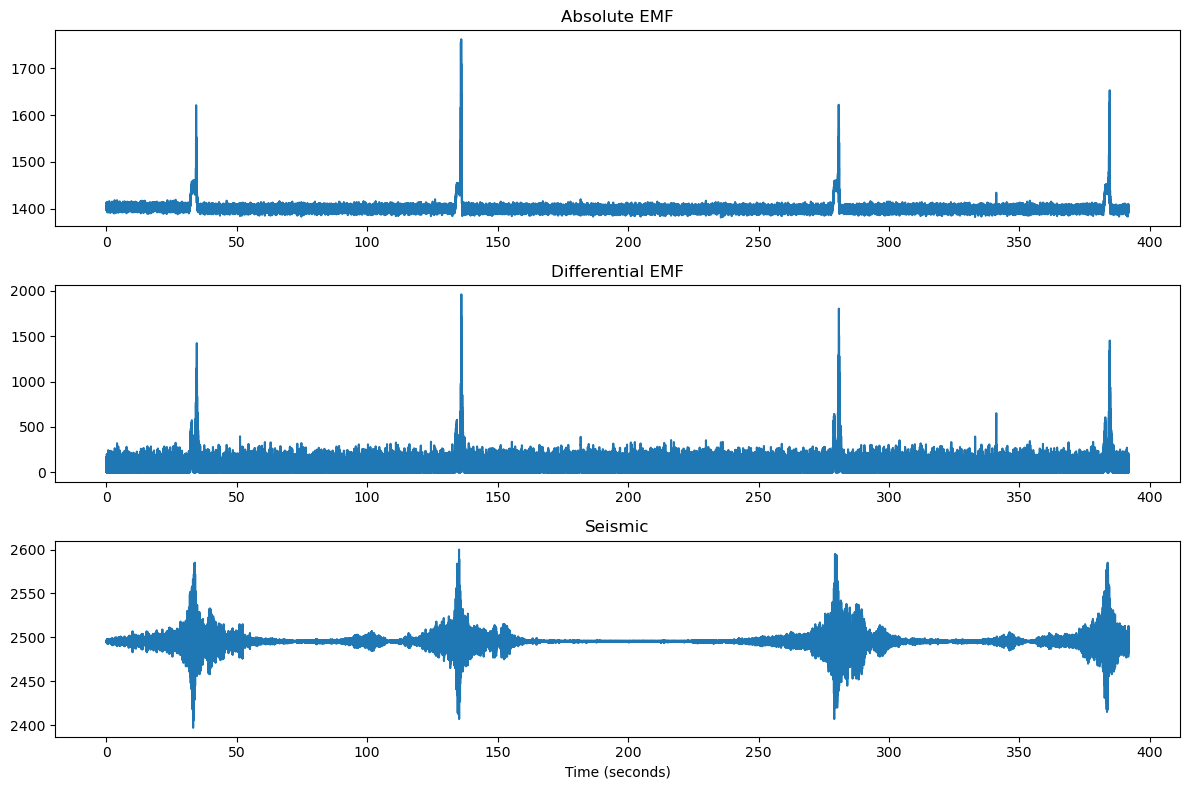

File: Data\Tank\BMP !! Tank Bhatinda\2nos 20, 2 nos 25 missditance 30cm.txt


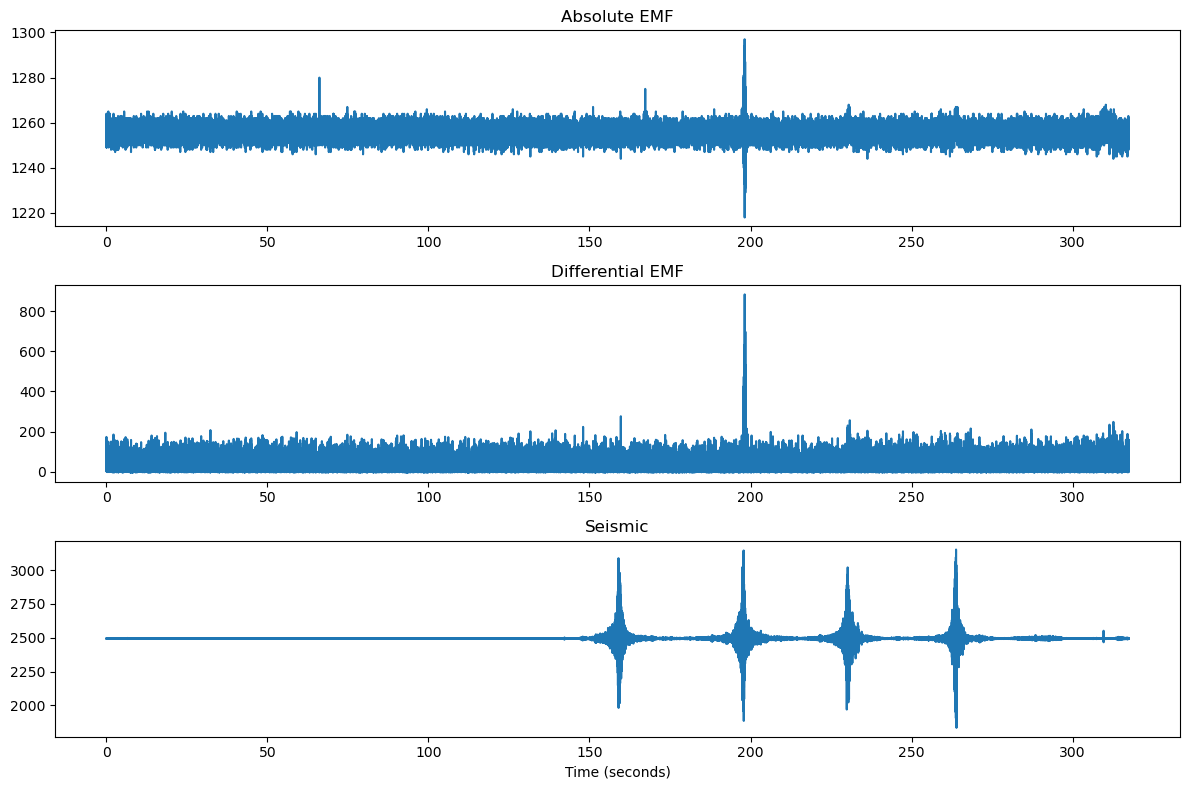

File: Data\Tank\BMP !! Tank Bhatinda\2nos 5km, 4 nos 10km, 4 nos 15km, 2nos 20km missdistance 30cm.txt


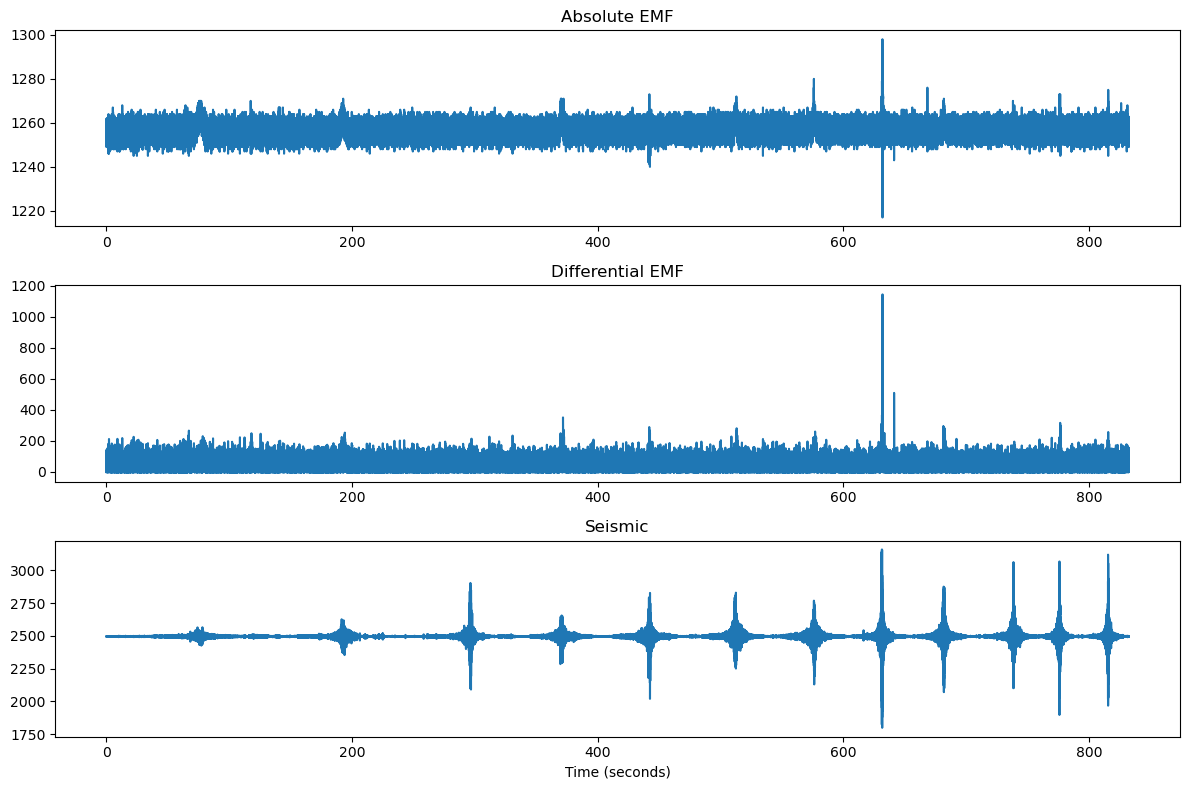

File: Data\Tank\BMP !! Tank Bhatinda\BMP 10km 6 run.txt


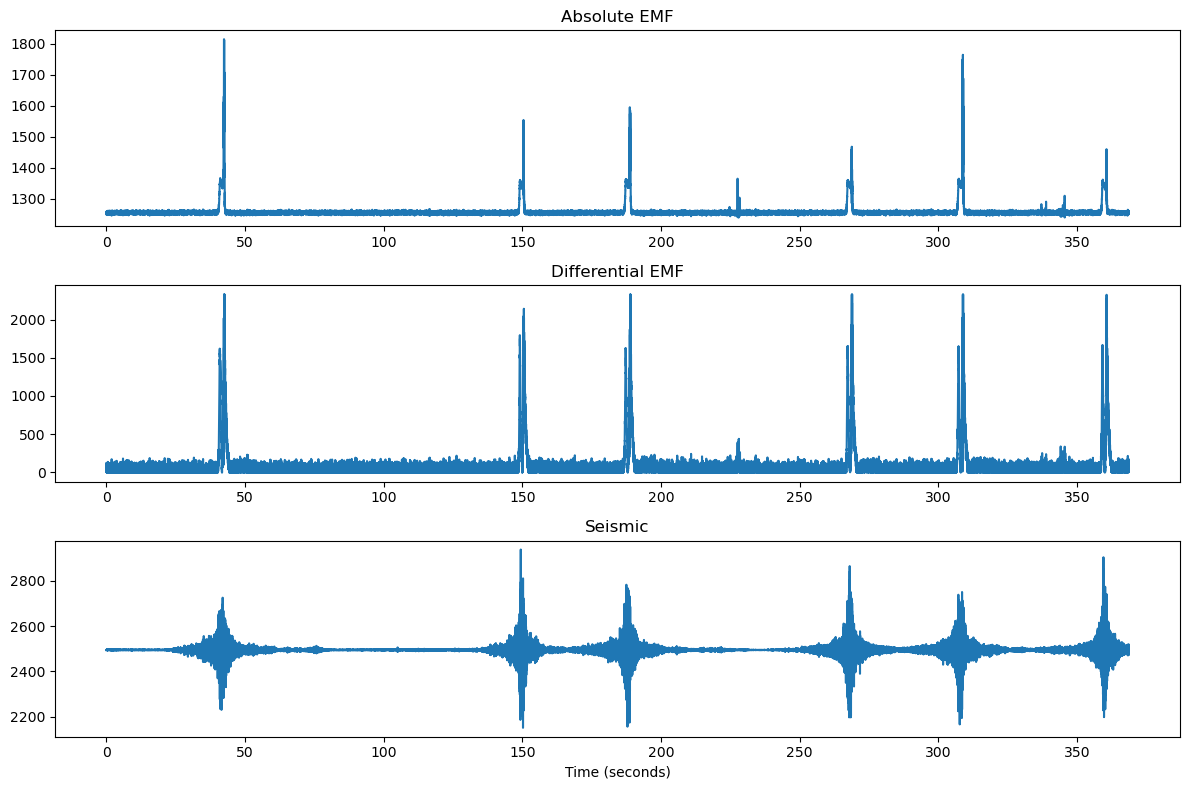

In [117]:
for i in range(4):
    print("File:", all_paths[i])
    visualize_signals(all_paths[i])

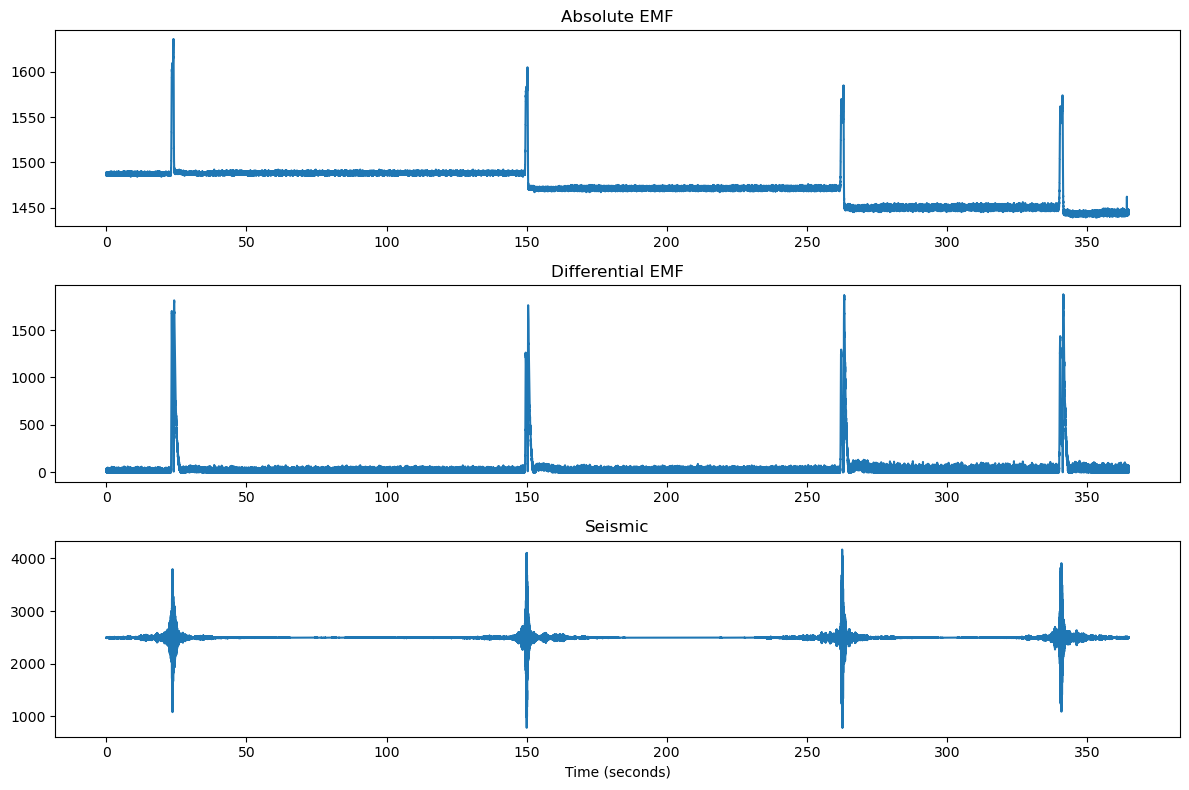

In [118]:

visualize_signals("Data/Tank/T72 tank/20km.txt")

In [119]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_signals(filepath):
    """
    Visualize Absolute EMF, Differential EMF, and Seismic signals
    with vertical offsets so spikes are easy to see.
    """

    rows = []

    # Read file safely (skip text lines)
    with open(filepath, "r") as f:
        for line in f:
            parts = line.strip().split()

            if len(parts) >= 4:
                try:
                    nums = [float(p) for p in parts[:4]]
                    rows.append(nums)
                except:
                    continue

    data = np.array(rows)

    # ignore last column
    data = data[:, :3]

    absolute = data[:,0]
    differential = data[:,1]
    seismic = data[:,2]

    # sampling rate = 1000 Hz
    time = np.arange(len(absolute)) / 1000

    # offsets to separate signals visually
    abs_offset = 1500
    seis_offset = 2500

    plt.figure(figsize=(14,6))

    plt.plot(time, absolute + abs_offset, label="Absolute EMF", color="gold")
    plt.plot(time, differential, label="Differential EMF", color="teal")
    plt.plot(time, seismic + seis_offset, label="Seismic", color="brown")

    plt.xlabel("Time (seconds)")
    plt.ylabel("Signal")
    plt.title("Vehicle Sensor Signals")

    plt.legend()
    plt.grid(True)

    plt.show()

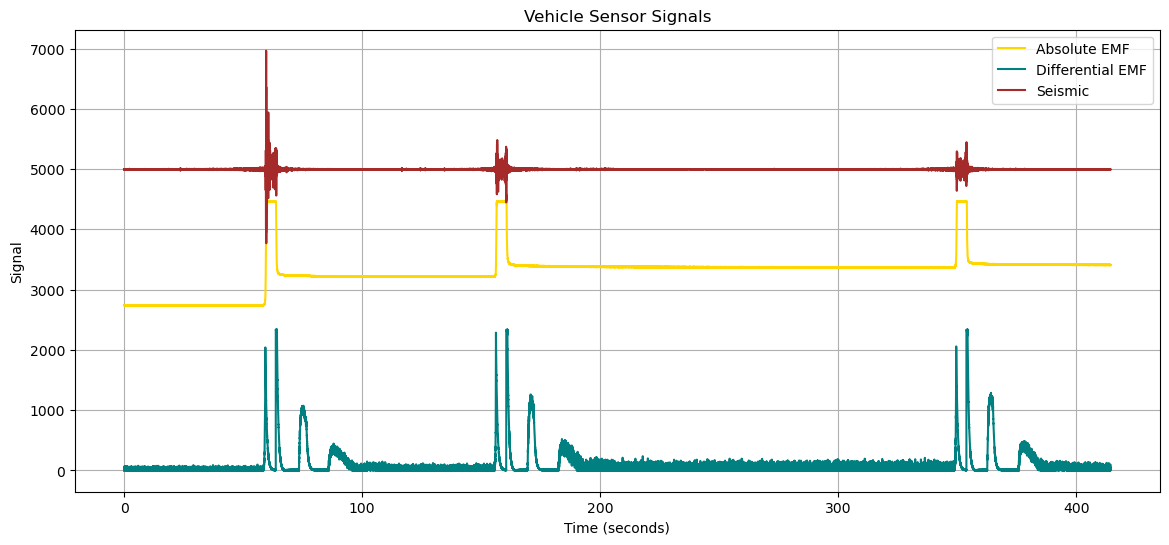

In [120]:
visualize_signals("Data/Tank/T72 tank/On Track 5km.txt")

C:\Users\Jaykumarintern\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


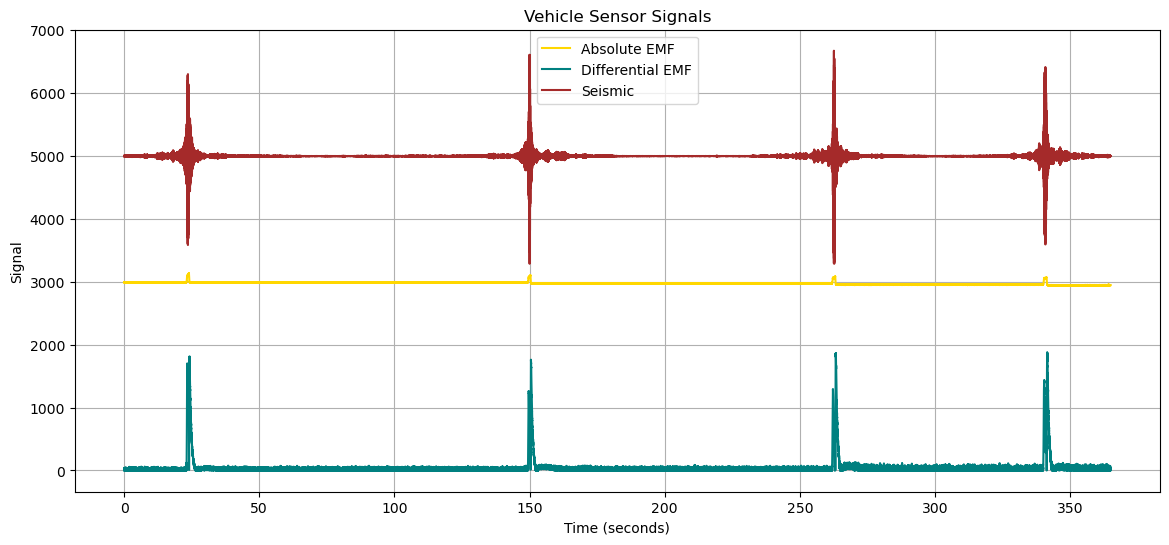

In [121]:
visualize_signals("Data/Tank/T72 tank/20km.txt")

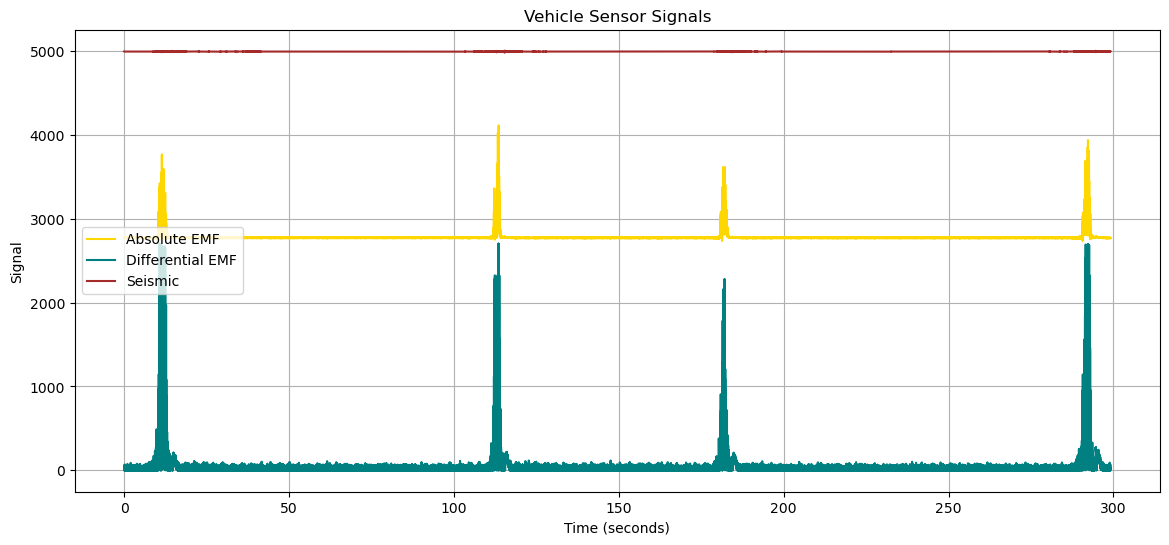

In [122]:
visualize_signals("Data/Truck/ALS truck Bhatinda/ALS 5km.txt")

### Detect First Strong Spike

In [123]:
def detect_first_spike(signal, threshold_ratio=6):
    """
    Detect first strong spike in a signal.

    threshold_ratio controls how strong spike must be
    relative to noise.
    """

    # estimate noise level
    # signal[:5000] → takes the first 5000 values of the signal.
    # np.std() → calculates the standard deviation (how much the values vary).
    # noise = the estimated noise level of the signal, calculated from the first 5000 samples.
        
    noise = np.std(signal[:5000])

    threshold = threshold_ratio * noise  #A spike is detected only if the signal is 6 times larger than the noise level.

    for i in range(len(signal)):
        if abs(signal[i]) > threshold:
            return i

    return None

### Test It Use Differential EMF.

In [124]:
signal = all_signals[0]

absolute = signal[:,0]
differential = signal[:,1]
seismic = signal[:,2]

spike_index = detect_first_spike(differential)

print("First spike index:", spike_index)
print("Spike value:", differential[spike_index])

First spike index: 26543
Spike value: 325.0


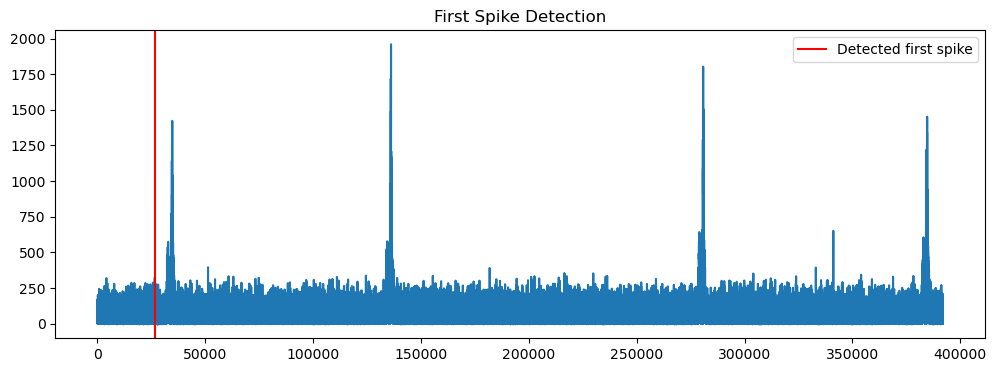

In [125]:
plt.figure(figsize=(12,4))

plt.plot(differential)
plt.axvline(spike_index, color="red", label="Detected first spike")

plt.legend()
plt.title("First Spike Detection")
plt.show()

In [126]:
from scipy.signal import find_peaks
import numpy as np

def detect_first_spike(signal):

    # detect peaks
    peaks, properties = find_peaks(signal, height=1000)

    if len(peaks) == 0:
        return None

    return peaks[0]

In [127]:
signal = all_signals[0]
differential = signal[:,1]

spike_index = detect_first_spike(differential)

print("First spike index:", spike_index)

First spike index: 34458


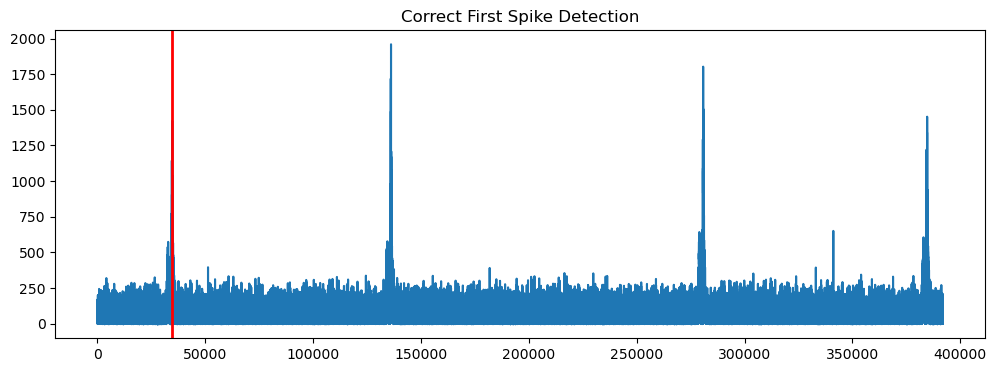

In [128]:
plt.figure(figsize=(12,4))

plt.plot(differential)
plt.axvline(spike_index, color="red", linewidth=2)

plt.title("Correct First Spike Detection")
plt.show()

### Detect Rising Edge (Vehicle Entry)


In [129]:
import numpy as np

def detect_vehicle_start(signal, rise_threshold=150):

    diff = np.diff(signal)

    for i in range(len(diff)):
        if diff[i] > rise_threshold:
            return i

    return None

In [130]:
signal = all_signals[0]
differential = signal[:,1]

start_index = detect_vehicle_start(differential)

print("Vehicle start:", start_index)

Vehicle start: 135950


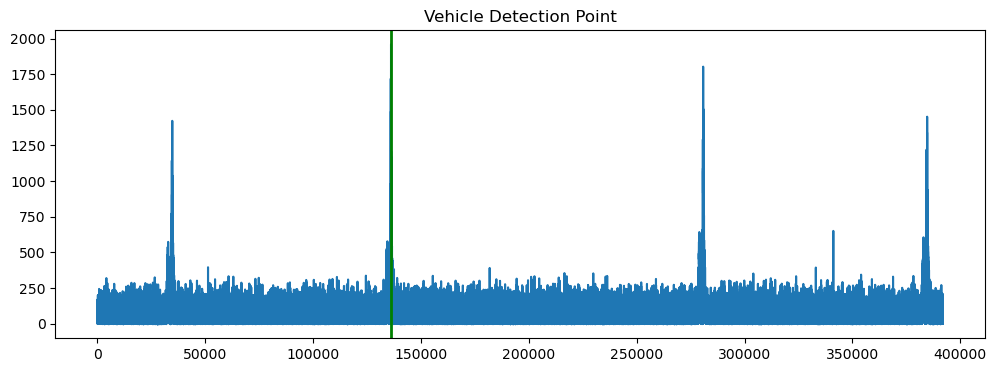

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.plot(differential)
plt.axvline(start_index, color="green", linewidth=2)

plt.title("Vehicle Detection Point")
plt.show()

### Moving enery detector

In [132]:
def detect_vehicle_start(signal, window=200, threshold_ratio=4):
    
    # compute baseline noise from first few seconds
    noise_level = np.mean(np.abs(signal[:5000]))
    
    threshold = threshold_ratio * noise_level

    for i in range(len(signal) - window):
        segment = signal[i:i+window]
        
        energy = np.mean(np.abs(segment))
        
        if energy > threshold:
            return i

    return None

In [133]:
signal = all_signals[0]
differential = signal[:,1]

start_index = detect_vehicle_start(differential)

print(start_index)

32202


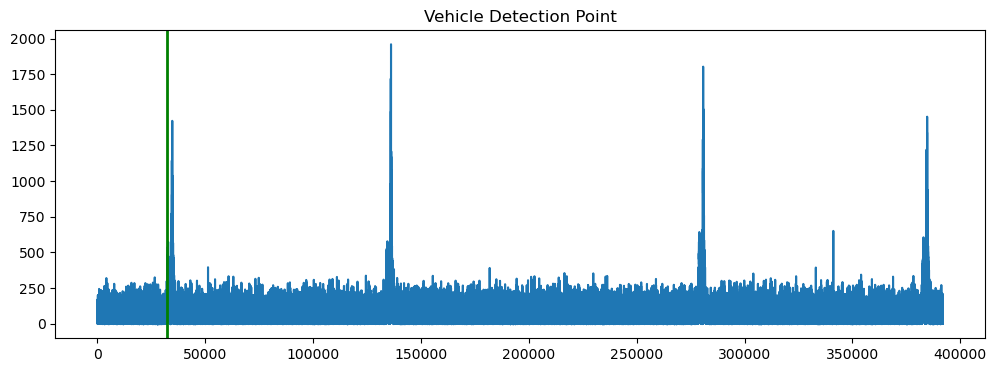

In [134]:
plt.figure(figsize=(12,4))

plt.plot(differential)
plt.axvline(start_index, color="green", linewidth=2)

plt.title("Vehicle Detection Point")
plt.show()

### Window Extraction Function

In [135]:
def extract_window(signal, center_index, before=50, after=100):
    """
    Extract window around detected vehicle start.
    
    before = samples before detection
    after  = samples after detection
    """

    start = max(0, center_index - before)
    end = min(len(signal), center_index + after)

    return signal[start:end]

In [136]:
signal = all_signals[0]

absolute = signal[:,0]
differential = signal[:,1]
seismic = signal[:,2]

abs_window = extract_window(absolute, start_index)
diff_window = extract_window(differential, start_index)
seis_window = extract_window(seismic, start_index)

In [137]:
print(len(abs_window))
print(len(diff_window))
print(len(seis_window))

150
150
150


### Visualize the Window

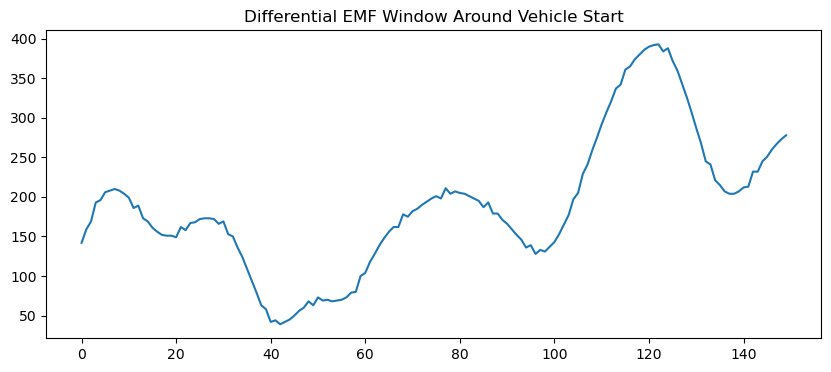

In [138]:
plt.figure(figsize=(10,4))

plt.plot(diff_window)
plt.title("Differential EMF Window Around Vehicle Start")

plt.show()

### Feature Function

In [139]:
import numpy as np
from scipy.stats import skew, kurtosis

def extract_features(signal):

    features = []

    # basic statistics
    features.append(np.mean(signal))
    features.append(np.std(signal))
    features.append(np.max(signal))
    features.append(np.min(signal))

    # signal range
    features.append(np.max(signal) - np.min(signal))

    # energy
    features.append(np.sum(signal**2))

    # shape features
    features.append(skew(signal))
    features.append(kurtosis(signal))

    return features

### 54 Features Per Signal
1️⃣ Basic Statistical Features  (10) 

    Mean, Median, Standard deviation, Variance, Maximum, Minimum, Range, RMS, Mean absolute value, Median absolute deviation

2️⃣ Amplitude / Shape Features (10)

    Peak amplitude, Peak-to-peak, Crest factor, Impulse factor, Shape factor, Clearance factor, Skewness, Kurtosis, Peak index position, Peak / mean ratio

3️⃣ Energy Features (8)

    Signal energy, Mean energy, Log energy, Absolute energy, Energy entropy, Teager energy, Signal power, RMS energy

4️⃣ Zero Crossing & Derivative Features (6)

    Zero crossing rate, Mean derivative, Std derivative, Max derivative, Min derivative, Derivative energy

5️⃣ Frequency Features (10)

    Using FFT., Dominant frequency, Spectral centroid, Spectral bandwidth, Spectral rolloff, Spectral flatness, Spectral entropy, Max FFT magnitude, Mean FFT magnitude, FFT energy, Frequency variance

6️⃣ Envelope Features (Hilbert Transform) (5)

    Envelope mean, Envelope max, Envelope std, Envelope energy, Envelope peak index

7️⃣ Window Shape Features (5)

    Signal slope, Signal area, Area absolute, Peak width estimate, Signal duration above mean

In [140]:
import numpy as np
from scipy.stats import skew, kurtosis
from scipy.signal import hilbert

def extract_54_features(signal, fs=1000):

    f = []

    # ---- Basic statistics ----
    mean = np.mean(signal)
    median = np.median(signal)
    std = np.std(signal)
    var = np.var(signal)
    max_val = np.max(signal)
    min_val = np.min(signal)

    range_val = max_val - min_val
    rms = np.sqrt(np.mean(signal**2))
    mean_abs = np.mean(np.abs(signal))
    mad = np.median(np.abs(signal - median))

    f += [mean, median, std, var, max_val, min_val, range_val, rms, mean_abs, mad]

    # ---- Amplitude ----
    peak = np.max(np.abs(signal))
    ptp = np.ptp(signal)

    crest = peak / rms
    impulse = peak / mean_abs
    shape = rms / mean_abs
    clearance = peak / (np.mean(np.sqrt(np.abs(signal)))**2)

    sk = skew(signal)
    kt = kurtosis(signal)

    peak_index = np.argmax(np.abs(signal))
    peak_mean_ratio = peak / (mean_abs + 1e-8)

    f += [peak, ptp, crest, impulse, shape, clearance, sk, kt, peak_index, peak_mean_ratio]

    # ---- Energy ----
    energy = np.sum(signal**2)
    mean_energy = np.mean(signal**2)
    log_energy = np.log(energy + 1)

    abs_energy = np.sum(np.abs(signal))
    power = energy / len(signal)

    teager = np.mean(signal[1:-1]**2 - signal[:-2]*signal[2:])

    rms_energy = rms**2
    energy_entropy = -np.sum((signal**2 / energy) * np.log(signal**2 / energy + 1e-12))

    f += [energy, mean_energy, log_energy, abs_energy, energy_entropy, teager, power, rms_energy]

    # ---- Derivative features ----
    diff = np.diff(signal)

    zcr = np.sum(np.diff(np.sign(signal)) != 0)
    diff_mean = np.mean(diff)
    diff_std = np.std(diff)
    diff_max = np.max(diff)
    diff_min = np.min(diff)
    diff_energy = np.sum(diff**2)

    f += [zcr, diff_mean, diff_std, diff_max, diff_min, diff_energy]

    # ---- FFT features ----
    fft_vals = np.fft.rfft(signal)
    fft_mag = np.abs(fft_vals)

    freqs = np.fft.rfftfreq(len(signal), d=1/fs)

    dom_freq = freqs[np.argmax(fft_mag)]
    centroid = np.sum(freqs * fft_mag) / (np.sum(fft_mag) + 1e-8)

    bandwidth = np.sqrt(np.sum(((freqs - centroid)**2) * fft_mag) / np.sum(fft_mag))

    rolloff = freqs[np.where(np.cumsum(fft_mag) >= 0.85*np.sum(fft_mag))[0][0]]

    flatness = np.exp(np.mean(np.log(fft_mag + 1e-12))) / np.mean(fft_mag)

    prob = fft_mag / np.sum(fft_mag)
    spec_entropy = -np.sum(prob * np.log2(prob + 1e-12))

    fft_max = np.max(fft_mag)
    fft_mean = np.mean(fft_mag)
    fft_energy = np.sum(fft_mag**2)
    freq_var = np.var(freqs)

    f += [dom_freq, centroid, bandwidth, rolloff, flatness, spec_entropy, fft_max, fft_mean, fft_energy, freq_var]

    # ---- Envelope ----
    env = np.abs(hilbert(signal))

    env_mean = np.mean(env)
    env_max = np.max(env)
    env_std = np.std(env)
    env_energy = np.sum(env**2)
    env_peak = np.argmax(env)

    f += [env_mean, env_max, env_std, env_energy, env_peak]

    # ---- Window shape ----
    slope = (signal[-1] - signal[0]) / len(signal)
    area = np.sum(signal)
    abs_area = np.sum(np.abs(signal))
    width = np.sum(signal > mean)
    duration = np.sum(signal > mean_abs)

    f += [slope, area, abs_area, width, duration]

    return f

In [141]:
abs_feat = extract_54_features(abs_window)
diff_feat = extract_54_features(diff_window)
seis_feat = extract_54_features(seis_window)

feature_vector = abs_feat + diff_feat + seis_feat

In [142]:
### Convert Dataset to Arrays

In [143]:
X = []   # feature vectors
y = []   # labels


In [144]:
# Loop through all signal
import numpy as np
for signal, label in zip(all_signals, all_labels):

    absolute = signal[:,0]
    differential = signal[:,1]
    seismic = signal[:,2]

    # detect vehicle start
    start_index = detect_vehicle_start(differential)

    if start_index is None:
        continue

    # extract window
    abs_window = extract_window(absolute, start_index)
    diff_window = extract_window(differential, start_index)
    seis_window = extract_window(seismic, start_index)

    # extract features (54 each)
    abs_feat = extract_54_features(abs_window)
    diff_feat = extract_54_features(diff_window)
    seis_feat = extract_54_features(seis_window)

    # combine features
    feature_vector = abs_feat + diff_feat + seis_feat

    X.append(feature_vector)
    y.append(label)

In [210]:
X = np.array(X)
y = np.array(y)

print(X.shape)

(255, 162)


In [146]:
print("fd")

fd


In [196]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 12.7 MB/s  0:00:00


In [230]:
# from xgboost import XGBClassifier
# import numpy as np

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, stratify=y, random_state=42
# )

# model = XGBClassifier(
#     n_estimators=300,
#     max_depth=6,
#     learning_rate=0.05
# )

# model.fit(X_train, y_train)

# pred = model.predict(X_test)

# print(classification_report(y_test, pred))

# importance = model.feature_importances_

# accuracy = model.score(X_test, y_test)

# print("Accuracy:", accuracy)



# XGBOOST 96% accuracy
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y,
#     test_size=0.2,
#     stratify=y,
#     random_state=42
# )

# model
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1
)



# evaluation
model.fit(X_train, y_train)

pred = model.predict(X_test)


accuracy = model.score(X_test, y_test)

print("Accuracy:", accuracy)

print(classification_report(y_test, pred))

# lightgbm
# from lightgbm import LGBMClassifier
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import classification_report

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, stratify=y, random_state=42
# )

# model = LGBMClassifier(
#     n_estimators=400,
#     max_depth=6,
#     learning_rate=0.05,
#     subsample=0.9,
#     colsample_bytree=0.9,
#     random_state=42,
#     n_jobs=-1
# )

# model.fit(X_train, y_train)

# pred = model.predict(X_test)

# print(classification_report(y_test, pred))

# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(
#     X_selected, y, test_size=0.2, random_state=42
# )

# model.fit(X_train, y_train)

# accuracy = model.score(X_test, y_test)

# print("Accuracy:", accuracy)


Accuracy: 0.9607843137254902
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        29
           1       0.95      0.95      0.95        22

    accuracy                           0.96        51
   macro avg       0.96      0.96      0.96        51
weighted avg       0.96      0.96      0.96        51



In [224]:
# Model 3
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=400,
    depth=6,
    learning_rate=0.05,
    random_seed=42,
    verbose=0
)

model.fit(X_train, y_train)

pred = model.predict(X_test)


accuracy = model.score(X_test, y_test)

print("Accuracy:", accuracy)

print(classification_report(y_test, pred))

Accuracy: 0.9607843137254902
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        29
           1       0.95      0.95      0.95        22

    accuracy                           0.96        51
   macro avg       0.96      0.96      0.96        51
weighted avg       0.96      0.96      0.96        51



In [205]:
# from sklearn.ensemble import RandomForestClassifier

# model = RandomForestClassifier(
#     n_estimators=400,
#     max_depth=10,
#     random_state=42,
#     n_jobs=-1
# )

# model.fit(X_train, y_train)

# pred = model.predict(X_test)

# accuracy = model.score(X_test, y_test)

# print("Accuracy:", accuracy)

# print(classification_report(y_test, pred))

Accuracy: 0.9411764705882353
              precision    recall  f1-score   support

           0       0.96      0.93      0.95        29
           1       0.91      0.95      0.93        22

    accuracy                           0.94        51
   macro avg       0.94      0.94      0.94        51
weighted avg       0.94      0.94      0.94        51



In [237]:
import pandas as pd
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier

# split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, stratify=y, random_state=42
)

models = {

    "XGBoost": XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1
    ),
    

    "LightGBM": LGBMClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42
    ),

    "CatBoost": CatBoostClassifier(
        iterations=400,
        depth=6,
        learning_rate=0.05,
        verbose=0,
        random_seed=42
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),

    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=400,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=3
    )
}

results = []

for name, model in models.items():

    start = time.time()

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    end = time.time()

    results.append({
        "Model": name,
        "Accuracy": round(acc,4),
        "Train Time (s)": round(end-start,2)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print(results_df)

[LightGBM] [Info] Number of positive: 98, number of negative: 106
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000318 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3520
[LightGBM] [Info] Number of data points in the train set: 204, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.480392 -> initscore=-0.078472
[LightGBM] [Info] Start training from score -0.078472
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

C:\Users\Jaykumarintern\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              Model  Accuracy  Train Time (s)
2          CatBoost    0.9216            3.57
4        ExtraTrees    0.9216            1.46
0           XGBoost    0.8824            0.47
1          LightGBM    0.8824            0.12
3      RandomForest    0.8627            2.29
5  GradientBoosting    0.8627            2.94


In [208]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)

print("Accuracy:", accuracy)

Accuracy: 0.9019607843137255


In [149]:
indices = np.argsort(importance)[::-1]

top_features = indices[:60]

X_selected = X[:, top_features]

print(X_selected.shape)

(255, 60)


In [227]:
# from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)

print("Accuracy:", accuracy)

Accuracy: 0.9607843137254902


In [150]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)

print("Accuracy:", accuracy)

Accuracy: 0.9607843137254902


In [151]:
model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [152]:
import joblib

joblib.dump(model, "vehicle_version2_xgboost_model.pkl")

['vehicle_version2_xgboost_model.pkl']

In [153]:
# model = joblib.load("vehicle_model.pkl")

In [154]:
# This reads signal sample by sample.
def stream_signal(signal):

    buffer = []

    for value in signal:
        buffer.append(value)

        if len(buffer) > 300:   # keep last 300 samples
            buffer.pop(0)

        yield np.array(buffer)

In [155]:
# Detect Vehicle Start We check if energy increases.

In [156]:
def vehicle_detected(window):

    energy = np.mean(np.abs(window))

    if energy > 500:   # adjust threshold
        return True

    return False

In [157]:
model = joblib.load("vehicle_version2_xgboost_model.pkl")

In [158]:
print(model.n_features_in_)

60


In [159]:
import joblib

joblib.dump(top_features, "top_features.pkl")

['top_features.pkl']

In [160]:
import joblib

model = joblib.load("vehicle_version2_xgboost_model.pkl")
top_features = joblib.load("top_features.pkl")

In [161]:
# Real-Time Prediction
signal = all_signals[0]

absolute = signal[:,0]
differential = signal[:,1]
seismic = signal[:,2]

stream = stream_signal(differential)

for window in stream:

    if len(window) < 200:
        continue

    if vehicle_detected(window):

        # extract windows
        abs_window = absolute[:200]
        diff_window = differential[:200]
        seis_window = seismic[:200]

        abs_feat = extract_54_features(abs_window)
        diff_feat = extract_54_features(diff_window)
        seis_feat = extract_54_features(seis_window)

        features = np.array(abs_feat + diff_feat + seis_feat).reshape(1,-1)

        prediction = model.predict(X_selected)

        

        if prediction[0] == 1:
            print("Tank detected")
        else:
            print("No tank detected")

        break

Tank detected


In [162]:
# abs_feat = extract_54_features(abs_window)
# diff_feat = extract_54_features(diff_window)
# seis_feat = extract_54_features(seis_window)

In [163]:
# import numpy as np

# features = np.array(abs_feat + diff_feat + seis_feat)

In [164]:
# features = features[top_features]

In [165]:
# features = features.reshape(1, -1)

In [166]:
# prediction = model.predict(features)

# if prediction[0] == 1:
#     print("Tank detected")
# else:
#     print("Non Tank detected")

In [167]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]   # probability for AUC

In [168]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9607843137254902


In [169]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.9545454545454546


In [170]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[28  1]
 [ 1 21]]


In [171]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        29
           1       0.95      0.95      0.95        22

    accuracy                           0.96        51
   macro avg       0.96      0.96      0.96        51
weighted avg       0.96      0.96      0.96        51



In [172]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)
print("AUC:", auc)

AUC: 0.9717868338557993


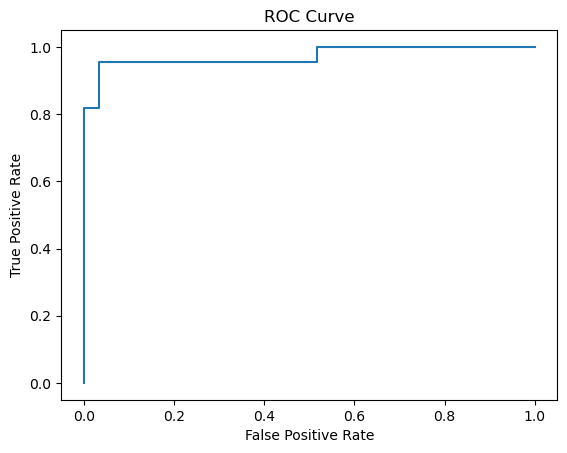

In [173]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [174]:
for i in range(10):
    print("Actual:", y_test[i], " Predicted:", y_pred[i])

Actual: 0  Predicted: 0
Actual: 1  Predicted: 1
Actual: 1  Predicted: 1
Actual: 0  Predicted: 0
Actual: 1  Predicted: 1
Actual: 0  Predicted: 0
Actual: 0  Predicted: 0
Actual: 0  Predicted: 0
Actual: 1  Predicted: 1
Actual: 1  Predicted: 1


In [175]:
def predict_vehicle(filepath):

    signal = read_vehicle_file(filepath)

    absolute = signal[:,0]
    differential = signal[:,1]
    seismic = signal[:,2]

    # detect vehicle start
    start_index = detect_vehicle_start(differential)

    if start_index is None:
        print("No vehicle detected")
        return

    # extract window
    abs_window = extract_window(absolute, start_index)
    diff_window = extract_window(differential, start_index)
    seis_window = extract_window(seismic, start_index)

    # extract features
    abs_feat = extract_54_features(abs_window)
    diff_feat = extract_54_features(diff_window)
    seis_feat = extract_54_features(seis_window)

    features = np.array(abs_feat + diff_feat + seis_feat)

    # select same 60 features used during training
    features = features[top_features]

    features = features.reshape(1,-1)

    # prediction
    prediction = model.predict(features)

    prob = model.predict_proba(features)

    if prediction[0] == 1:
        print("Prediction: Tank")
    else:
        print("Prediction: Non Tank")

    print("Tank Probability:", prob[0][1])

In [176]:
predict_vehicle(r"Data\Tank\T72 tank\20km.txt")

Prediction: Tank
Tank Probability: 0.995494


In [177]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def analyze_detection(filepath):

    signal = read_vehicle_file(filepath)

    absolute = signal[:,0]
    differential = signal[:,1]
    seismic = signal[:,2]

    # detect vehicle start
    start_index = detect_vehicle_start(differential)

    if start_index is None:
        print("No vehicle detected")
        return

    # window parameters
    before = 50
    after = 100

    start = max(0, start_index - before)
    end = min(len(differential), start_index + after)

    # detection time
    detection_time_ms = start_index   # because 1 sample = 1 ms

    print("Detection sample index:", start_index)
    print("Detection time (ms):", detection_time_ms)
    print("Window start (ms):", start)
    print("Window end (ms):", end)
    print("Window length (ms):", end-start)

    time = np.arange(len(differential))

    fig, ax = plt.subplots(figsize=(12,5))

    ax.plot(time, differential, label="Differential EMF")

    # detection line
    ax.axvline(start_index, color='red', label="Detection point")

    # rectangular window
    rect = Rectangle((start, min(differential)),
                     end-start,
                     max(differential)-min(differential),
                     linewidth=2,
                     edgecolor='green',
                     facecolor='none')

    ax.add_patch(rect)

    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Signal value")
    ax.set_title("Vehicle Detection Window")
    ax.legend()

    plt.show()

    # magnified view
    plt.figure(figsize=(10,4))
    plt.plot(time[start:end], differential[start:end])
    plt.axvline(start_index, color='red')
    plt.title("Magnified Detection Window")
    plt.xlabel("Time (ms)")
    plt.ylabel("Signal")
    plt.show()

Detection sample index: 22961
Detection time (ms): 22961
Window start (ms): 22911
Window end (ms): 23061
Window length (ms): 150


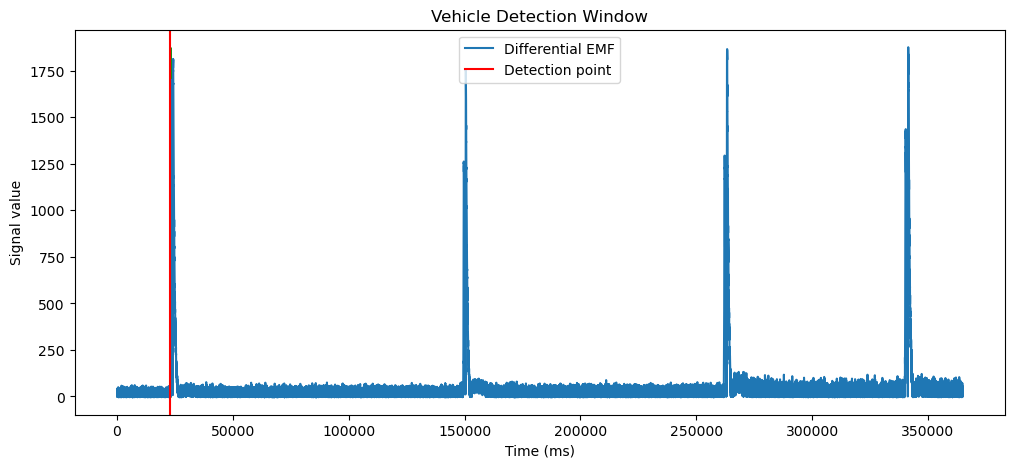

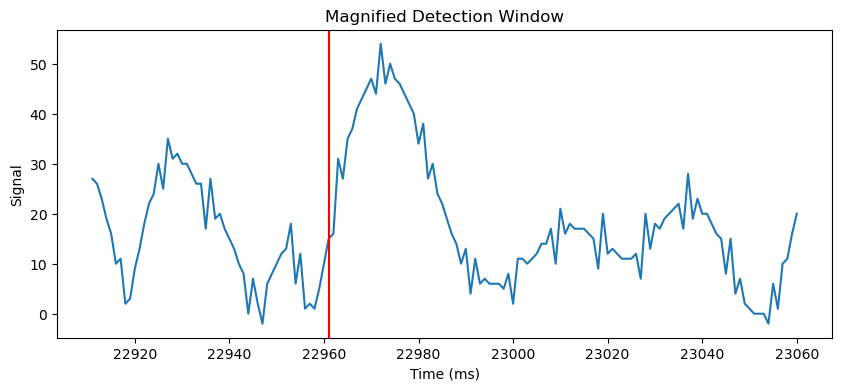

In [178]:
analyze_detection(r"Data\Tank\T72 tank\20km.txt")

In [193]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def visualize_all_signals(filepath):

    signal = read_vehicle_file(filepath)

    absolute = signal[:,0]
    differential = signal[:,1]
    seismic = signal[:,2]

    # detect vehicle start
    start_index = detect_vehicle_start(differential)

    before = 50
    after = 100

    start = max(0, start_index - before)
    end = min(len(signal), start_index + after)

    print("Detection sample:", start_index)
    print("Detection time (ms):", start_index)
    print("Window:", start, "to", end)

    time = np.arange(len(signal))

    fig, axs = plt.subplots(3,1, figsize=(12,8), sharex=True)

    signals = [absolute, differential, seismic]
    titles = ["Absolute EMF", "Differential EMF", "Seismic"]

    for i in range(3):
        axs[i].plot(time, signals[i])
        axs[i].axvline(start_index, color='red', label="Detection")

        rect = Rectangle((start, min(signals[i])),
                         end-start,
                         max(signals[i]) - min(signals[i]),
                         linewidth=2,
                         edgecolor='green',
                         facecolor='none')

        axs[i].add_patch(rect)

        axs[i].set_title(titles[i])
        axs[i].legend()

    axs[2].set_xlabel("Time (ms)")
    plt.tight_layout()
    plt.show()

    # magnified window
    fig, axs = plt.subplots(3,1, figsize=(12,8), sharex=True)

    for i in range(3):
        axs[i].plot(time[start:end], signals[i][start:end])
        axs[i].axvline(start_index, color='green')
        axs[i].set_title(titles[i] + " (Magnified Window)")

    axs[2].set_xlabel("Time (ms)")
    plt.tight_layout()
    plt.show()

Prediction: Non Tank
Tank Probability: 0.005036049
Detection sample: 19479
Detection time (ms): 19479
Window: 19429 to 19579


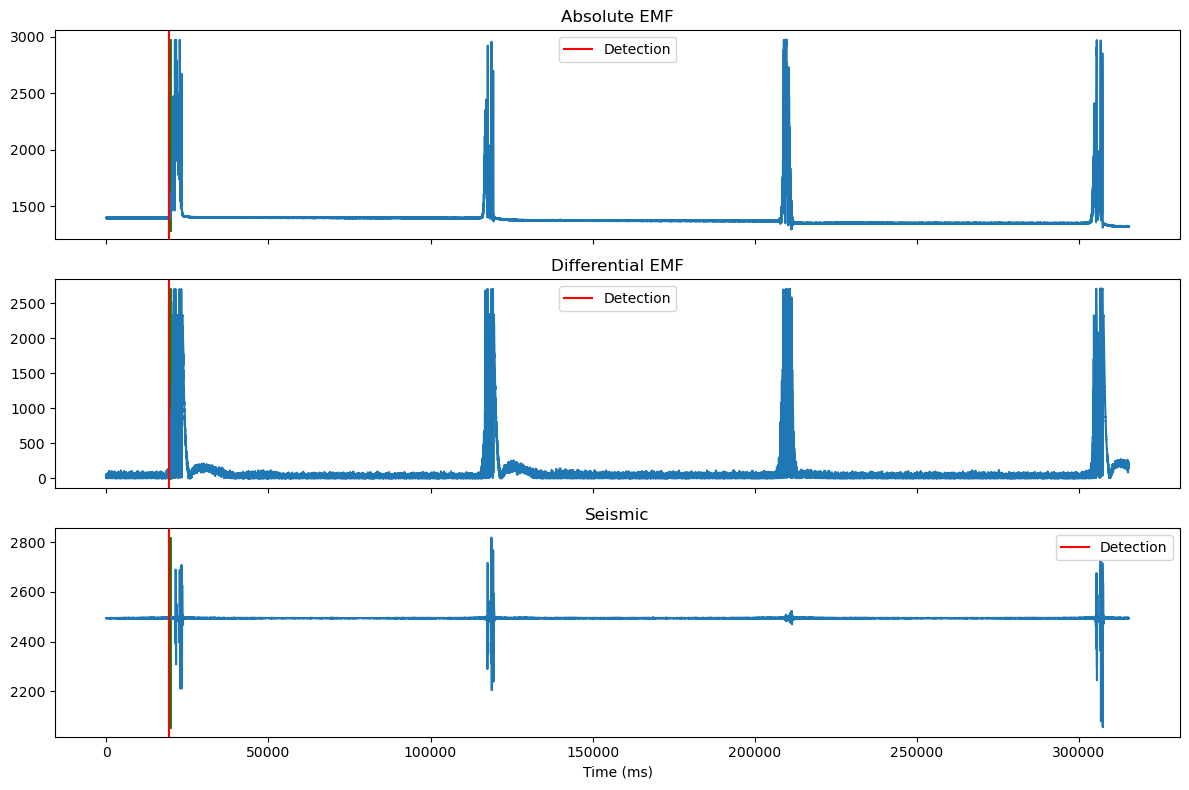

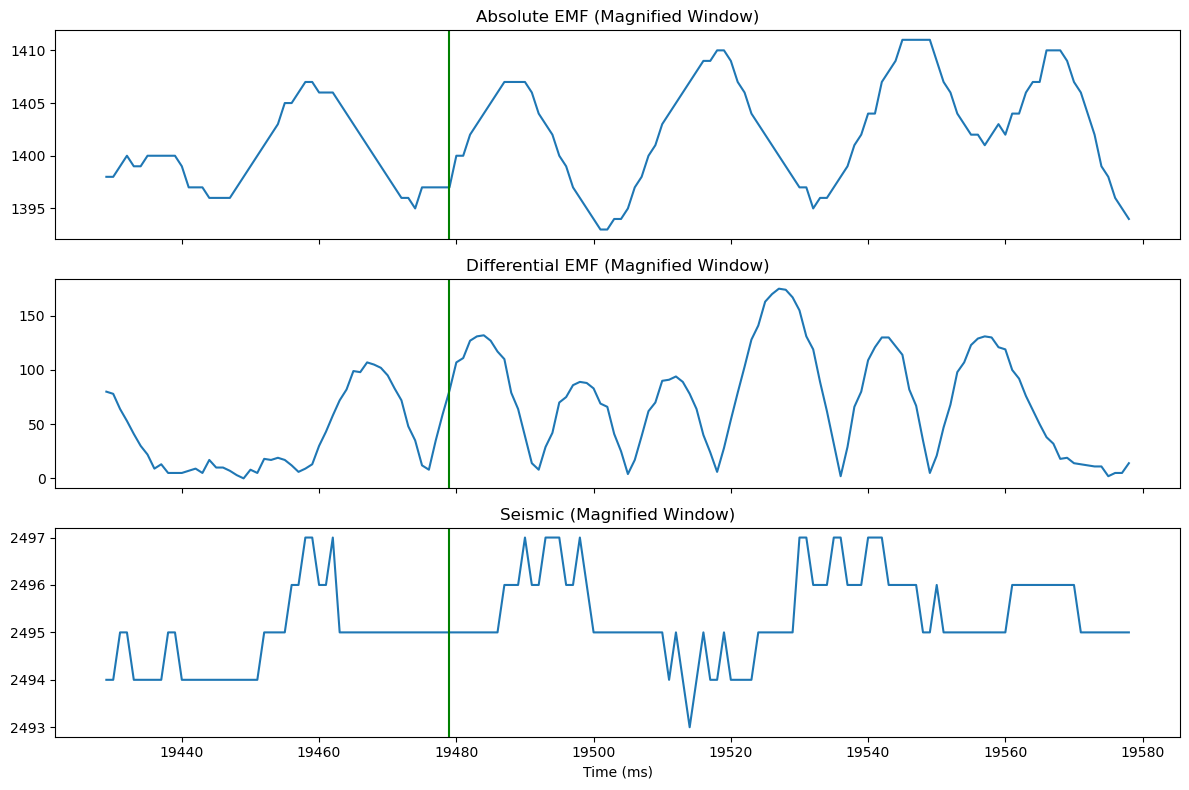

In [194]:
predict_vehicle(r"Data\Testing\Truck\10km on track 4 run tatra 6x6 bhatinda.txt")
visualize_all_signals(r"Data\Testing\Truck\10km on track 4 run tatra 6x6 bhatinda.txt")


Detection sample index: 28188
Detection time (ms): 28188
Window start (ms): 28138
Window end (ms): 28288
Window length (ms): 150


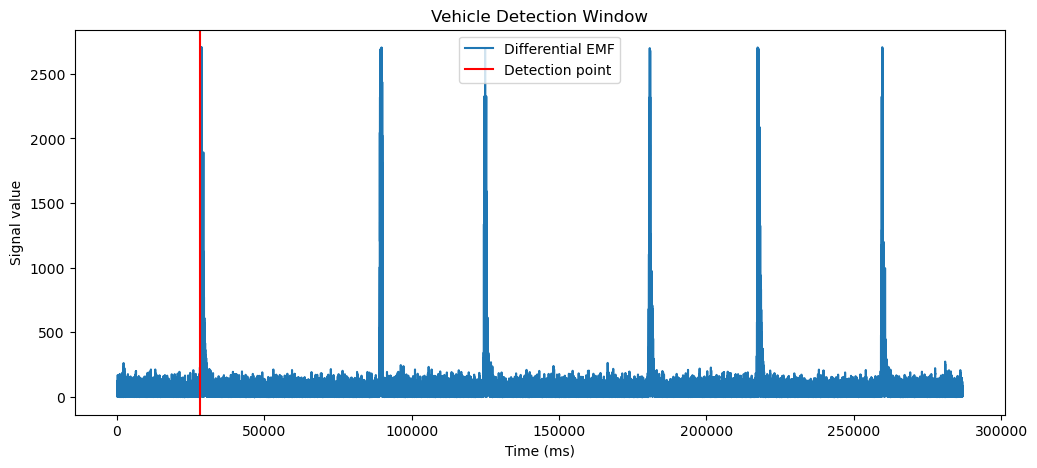

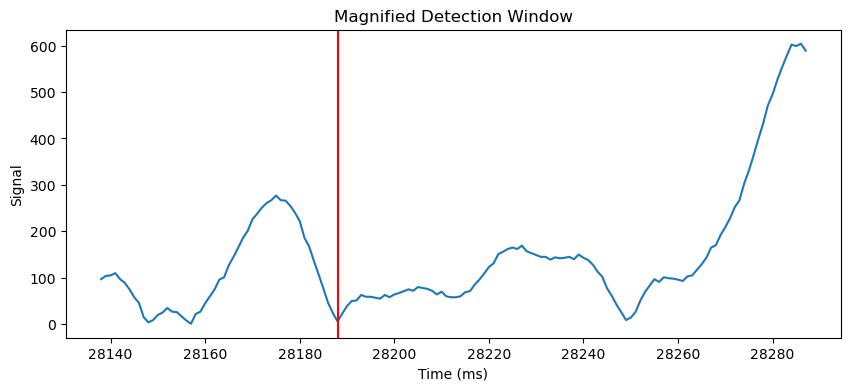

In [181]:
analyze_detection(r"Data\Testing\Truck\25km 6x6.txt")

In [ ]:
predict_vehicle(r"Data\Testing\Truck\6x6 35km patiala.txt")
visualize_all_signals(r"Data\Testing\Truck\6x6 35km patiala.txt")


Prediction: Non Tank
Tank Probability: 0.080087975
Detection sample: 59834
Detection time (ms): 59834
Window: 59784 to 59934


Prediction: Tank
Tank Probability: 0.9844742
Detection sample: 31115
Detection time (ms): 31115
Window: 31065 to 31215


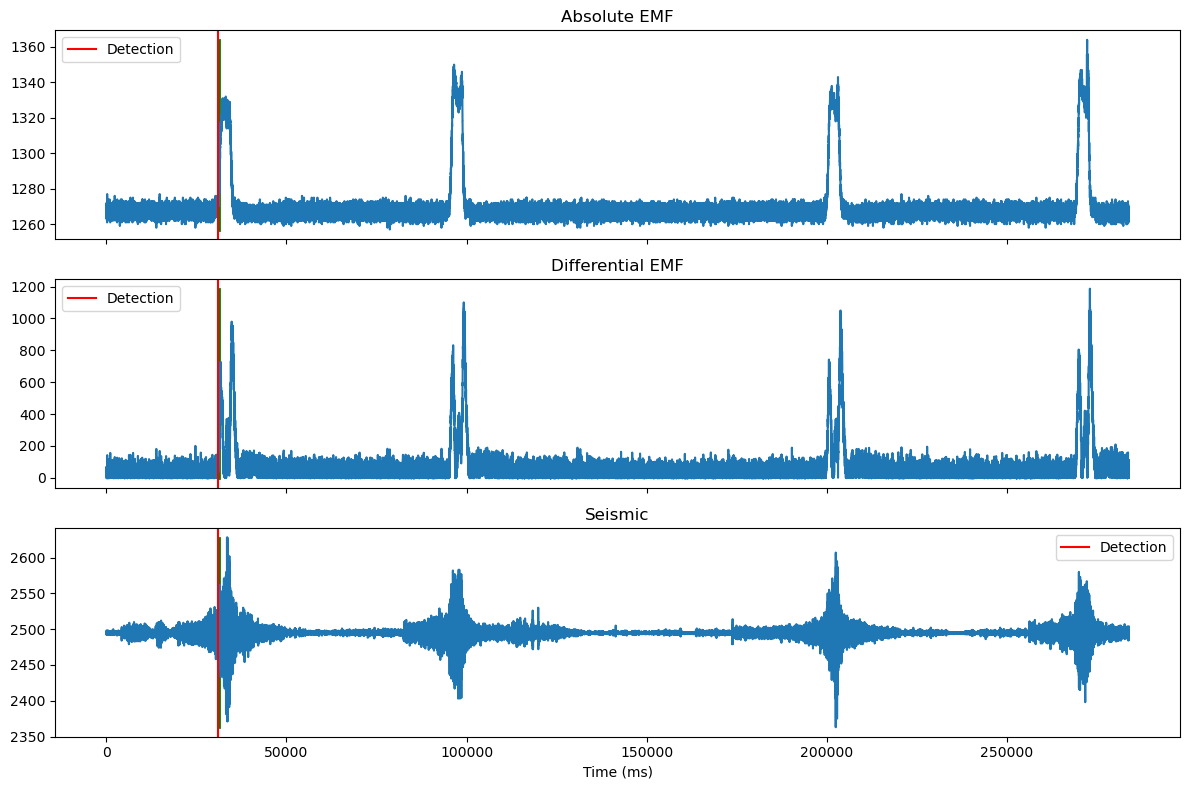

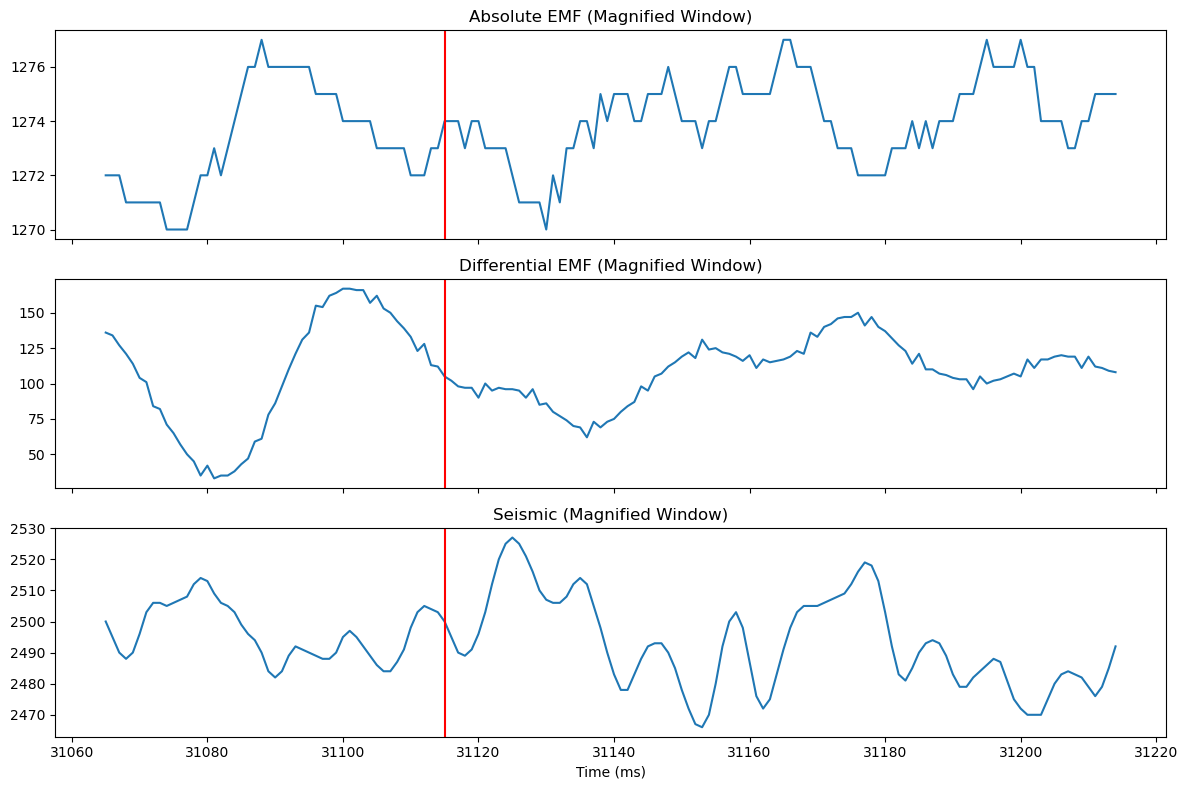

In [188]:
predict_vehicle(r"Data\Tank\T90 tank Jaisalmer\T90 4 run 5km.txt")
visualize_all_signals(r"Data\Tank\T90 tank Jaisalmer\T90 4 run 5km.txt")


Prediction: Tank
Tank Probability: 0.8600782
Detection sample: 19846
Detection time (ms): 19846
Window: 19796 to 19946


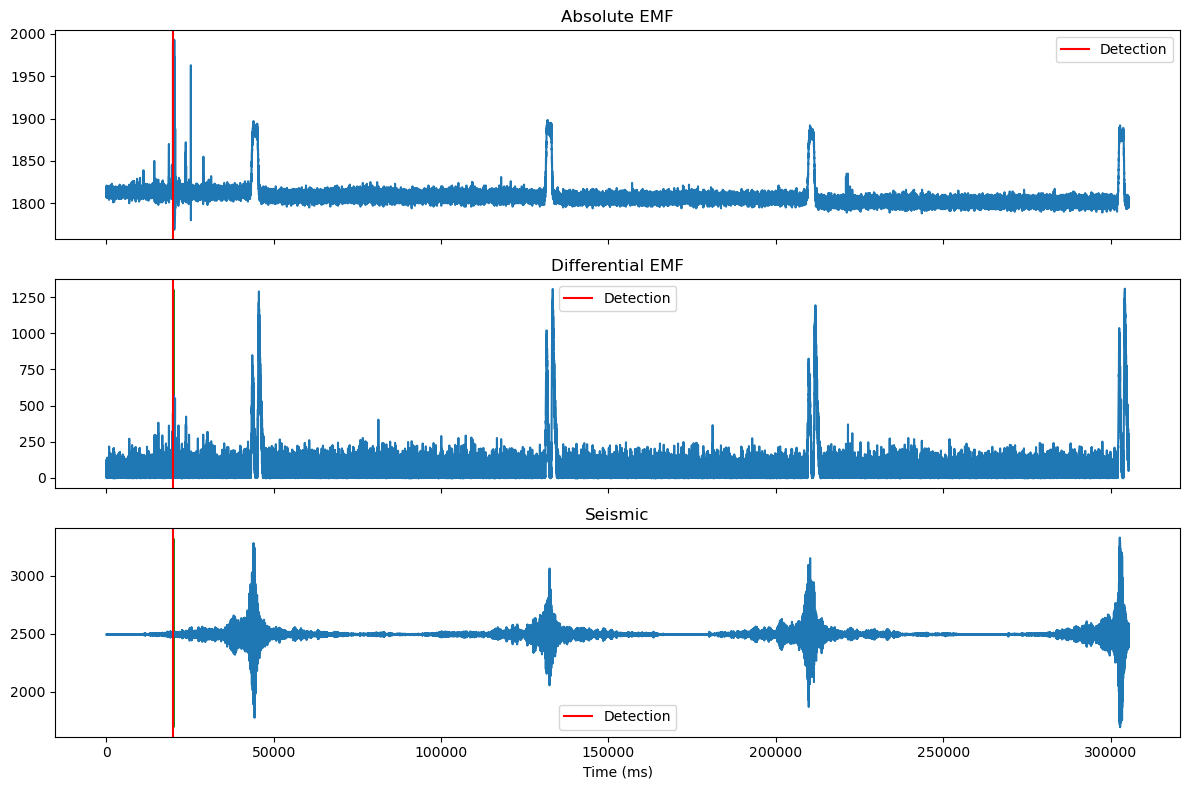

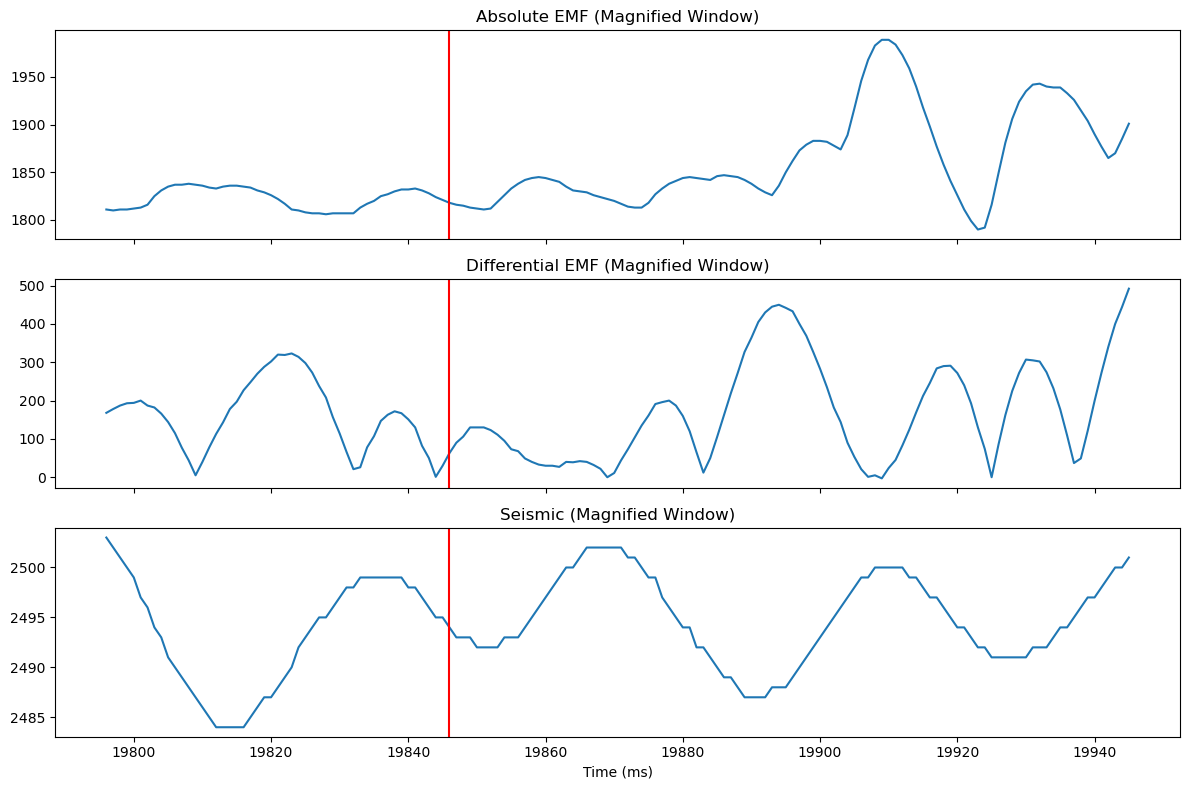

In [189]:
predict_vehicle(r"Data\Tank\T72 tank\T72 Belly 10km.txt")
visualize_all_signals(r"Data\Tank\T72 tank\T72 Belly 10km.txt")


Prediction: Non Tank
Tank Probability: 0.064522594
Detection sample: 79100
Detection time (ms): 79100
Window: 79050 to 79200


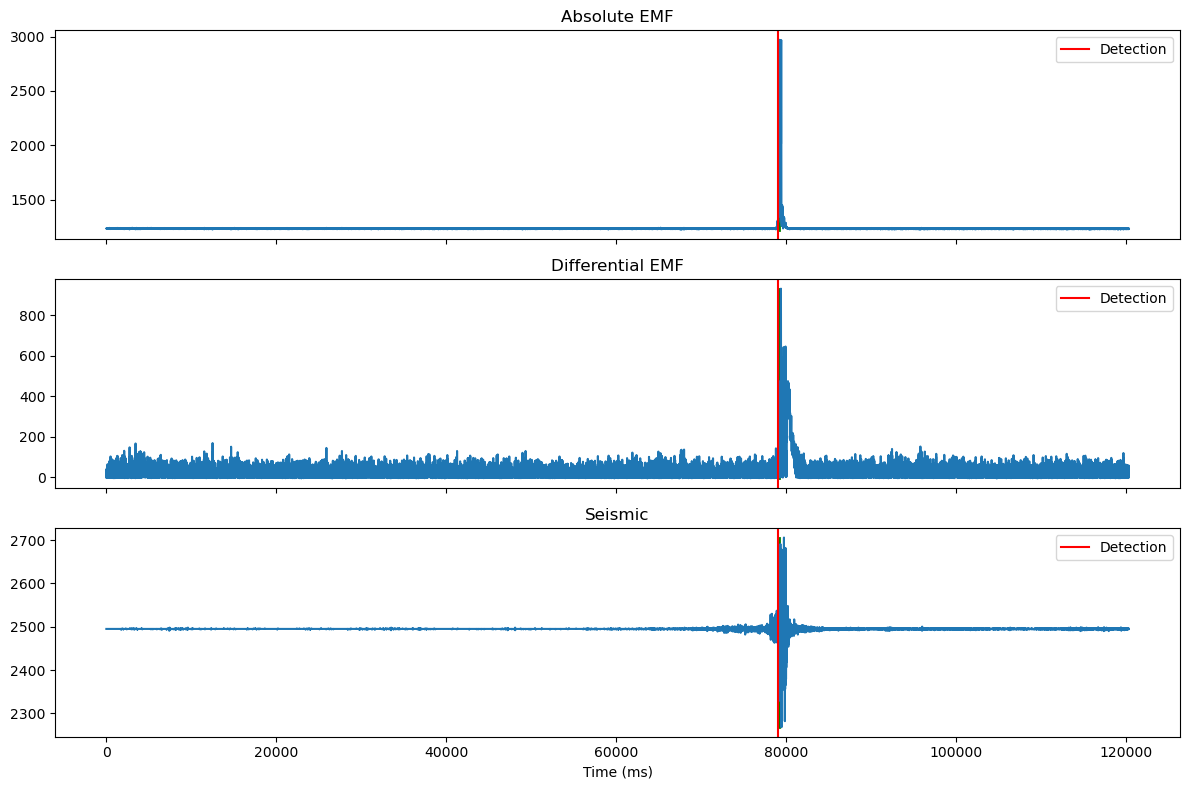

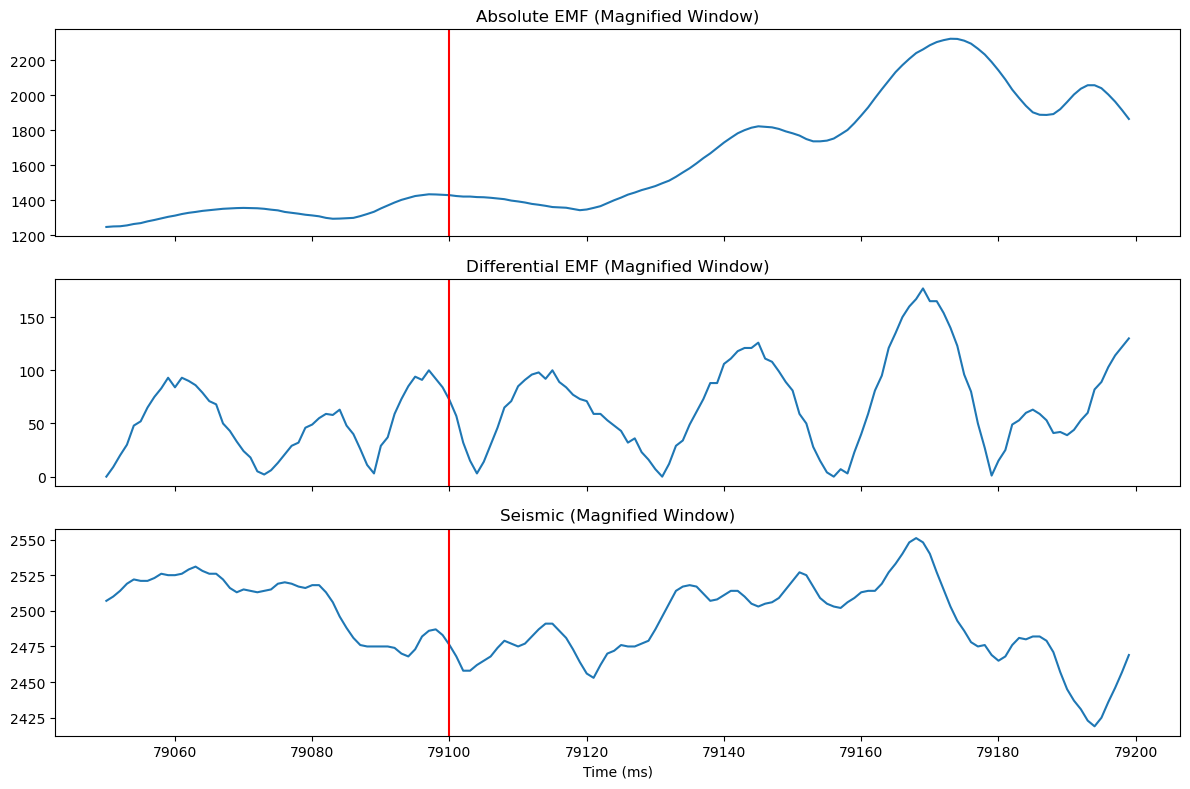

In [192]:
predict_vehicle(r"Data\Truck\AM50 Patiala Automobile 50Ton Bridge truck\AM50 1 run 40km.txt")
visualize_all_signals(r"Data\Truck\AM50 Patiala Automobile 50Ton Bridge truck\AM50 1 run 40km.txt")


In [187]:
print("i want to know what pattern it has seen in all 3 waveform during prediction is there any energy calcultion happening")
print("just after prediction i like to know the reason why it is tank or nontank with all test cases")

i want to know what pattern it has seen in all 3 waveform during prediction is there any energy calcultion happening
just after prediction i like to know the reason why it is tank or nontank with all test cases
